In [77]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from prophet import Prophet
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np
import warnings

# Игнорировать некоторые предупреждения
# warnings.filterwarnings("ignore")


try:
    data = pd.read_csv('C:/Users/epg_F/Homework_9/homework/data.csv', names=['time', 'value'], header=0)

    data['time'] = pd.to_datetime(data['time'], format='%Y-%m-%d %H:%M:%S', errors='coerce')
    data['value'] = pd.to_numeric(data['value'], errors='coerce')

    data.dropna(inplace=True)
    data = data.sort_values('time').reset_index(drop=True)

    print("Первые 5 строк данных после загрузки и предобработки:")
    print(data.head())

except FileNotFoundError:
    print("Ошибка: Файл 'data.csv' не найден по указанному пути. Проверьте путь.")
   
except Exception as e:
    print(f"Произошла ошибка при загрузке или предобработке данных: {e}")

Первые 5 строк данных после загрузки и предобработки:
                 time   value
0 2011-01-01 00:00:00  3416.0
1 2011-01-01 00:15:00  4755.0
2 2011-01-01 00:30:00  4939.0
3 2011-01-01 00:45:00  4939.0
4 2011-01-01 01:00:00  4998.0


Данные с индексом времени (первые 5 строк):
                      value
time                       
2011-01-01 00:00:00  3416.0
2011-01-01 00:15:00  4755.0
2011-01-01 00:30:00  4939.0
2011-01-01 00:45:00  4939.0
2011-01-01 01:00:00  4998.0


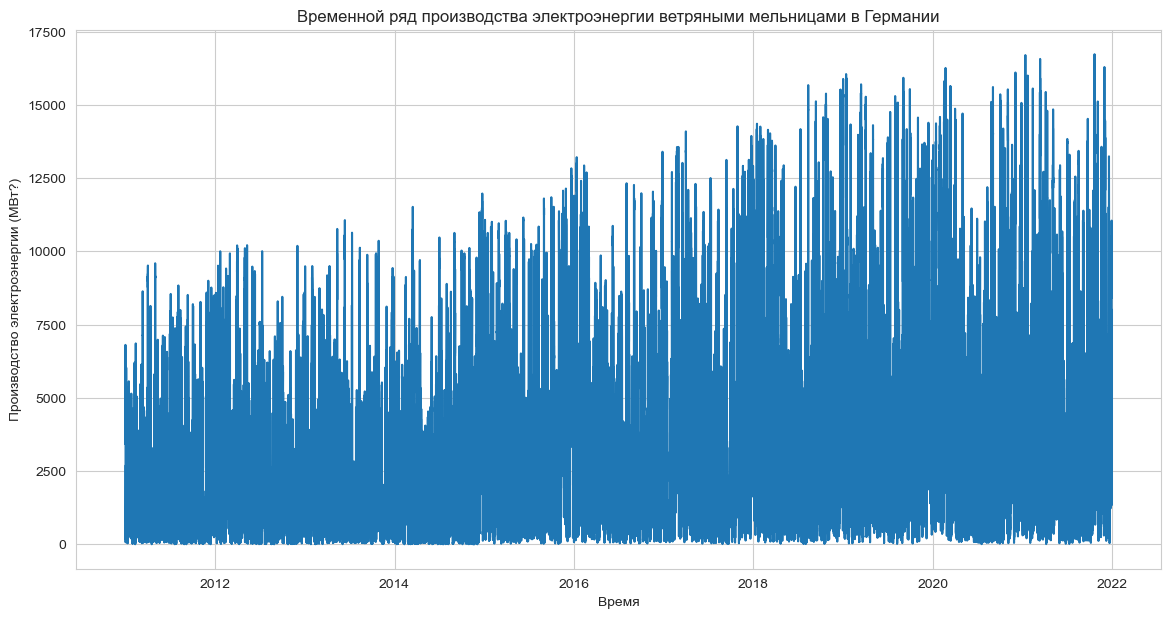

In [79]:

# Устанавливаем 'time' в качестве индекса
data_indexed = data.set_index('time')

print("Данные с индексом времени (первые 5 строк):")
print(data_indexed.head())

# Строим график временного ряда
plt.figure(figsize=(14, 7))
plt.plot(data_indexed.index, data_indexed['value'])
plt.title('Временной ряд производства электроэнергии ветряными мельницами в Германии')
plt.xlabel('Время')
plt.ylabel('Производство электроэнергии (МВт?)') 
plt.grid(True)
plt.show()

In [81]:

print("Основные статистики:")
print(data_indexed['value'].describe())
print(f"\nКоличество пропусков (после очистки): {data_indexed['value'].isnull().sum()}")
print(f"Начало временного ряда: {data_indexed.index.min()}")
print(f"Конец временного ряда: {data_indexed.index.max()}")
print(f"Период охвата временного ряда: {data_indexed.index.max() - data_indexed.index.min()}")

Основные статистики:
count    385566.000000
mean       3183.560481
std        3045.941591
min           0.000000
25%         905.000000
50%        2164.000000
75%        4529.877500
max       16727.500000
Name: value, dtype: float64

Количество пропусков (после очистки): 0
Начало временного ряда: 2011-01-01 00:00:00
Конец временного ряда: 2021-12-30 07:45:00
Период охвата временного ряда: 4016 days 07:45:00


In [83]:

print("Проверка частоты данных (разница между метками времени):")
print(data_indexed.index.to_series().diff().describe())

# данные имеют постоянную частоту 15 минут.
# 4 точки в час или 96 точкам в сутках (24 * 4 = 96).

Проверка частоты данных (разница между метками времени):
count                       385565
mean     0 days 00:15:00.004668473
std      0 days 00:00:22.266413135
min                0 days 00:00:00
25%                0 days 00:15:00
50%                0 days 00:15:00
75%                0 days 00:15:00
max                0 days 01:15:00
Name: time, dtype: object


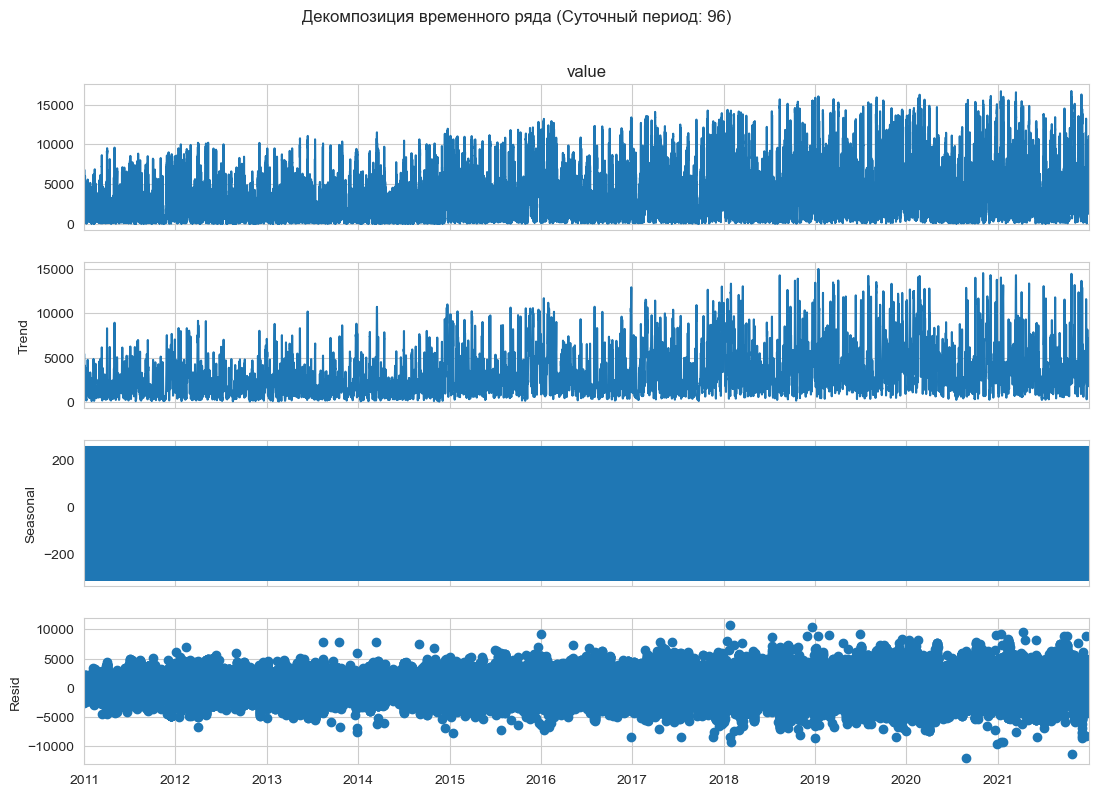

Декомпозиция с суточным периодом (96) выполнена.


In [85]:

DAILY_PERIOD = 96 # 15 минут * 4 = 1 час; 1 час * 24 = 96 точек в сутках

try:
    decomposition_daily = seasonal_decompose(data_indexed['value'].dropna(), model='additive', period=DAILY_PERIOD)
    fig_daily = decomposition_daily.plot()
    fig_daily.set_size_inches(12, 8)
    plt.suptitle(f'Декомпозиция временного ряда (Суточный период: {DAILY_PERIOD})', y=1.02)
    plt.show()
    print(f"Декомпозиция с суточным периодом ({DAILY_PERIOD}) выполнена.")

except Exception as e:
    print(f"Ошибка при декомпозиции с суточным периодом: {e}")
    print("Возможно, проблема с данными или слишком короткий ряд для данного периода.")

Необходимо дать пояснение по поводу графика суточной сезонности, который имеет такой странный вид. Такой график говорит о слабой суточной сезонности относительно других факторов.График декомпозиции показывает суточную сезонность, повторяющуюся 96 раз в день, на протяжении многих лет, ее визуализация на таком длинном промежутке времени сжимает множество циклов в узкое пространство.

На графике тренда четко видна общая восходящая тенденция на протяжении всего периода наблюдения (с 2011 по 2021 год). 

Остатки представляют собой случайные, нерегулярные колебания или "шум", которые не могут быть объяснены трендом или выбранной сезонностью. В нашем случае с ростом выработки электроэнергии растут и случайные колебания, что видно на графике.


 Анализ автокорреляции (ACF) и частичной автокорреляции (PACF) - Короткие лаги ---


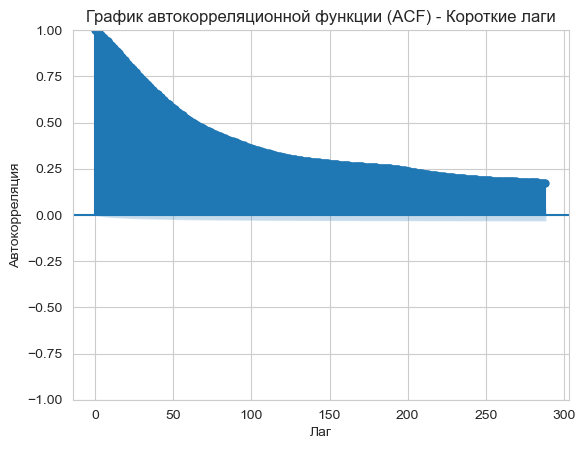

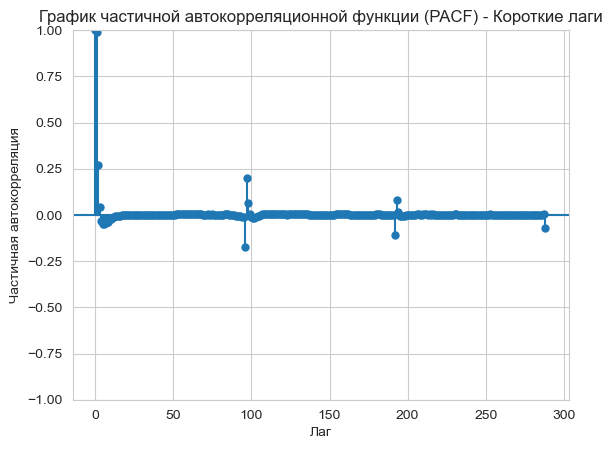

In [88]:

print(" Анализ автокорреляции (ACF) и частичной автокорреляции (PACF) - Короткие лаги ---")

plot_acf(data_indexed['value'].dropna(), lags=96*3) # Смотрим до ~3 дней (96 точек/день * 3)
plt.title('График автокорреляционной функции (ACF) - Короткие лаги')
plt.xlabel('Лаг')
plt.ylabel('Автокорреляция')
plt.grid(True)
plt.show()

plot_pacf(data_indexed['value'].dropna(), lags=96*3) # Смотрим до ~3 дней
plt.title('График частичной автокорреляционной функции (PACF) - Короткие лаги')
plt.xlabel('Лаг')
plt.ylabel('Частичная автокорреляция')
plt.grid(True)
plt.show()

График (ACF) - Короткие лаги:
Очень высокое значение автокорреляции на лаге 1, которое затем медленно затухает. Столбики долгое время остаются выше синей доверительной полосы. Это главный признак нестационарности ряда из-за наличия сильного тренда. Суточная сезонность присутствует, но ее влияние не так велико, как влияние тренда.

График (PACF) - Короткие лаги:
На этом графике столбик на лаге 1 очень высокий, а затем значения резко падают и остаются в пределах доверительного интервала (за исключением нескольких небольших выбросов). Такое поведение характерно для авторегрессионного процесса порядка 1 (AR(1)). Это говорит о сильной зависимости текущего значения от предыдущего.

Графики подтверждают, что  временной ряд имеет:
Сильный тренд, который делает его нестационарным.
Авторегрессионную структуру (AR(1)) на коротких лагах.
Суточную сезонность, которая статистически присутствует (ACF), но визуально и по силе кажется менее доминирующей по сравнению с трендом.

Принимаем решение о выборе модели Prophet, которая способна эффективно моделировать все эти компоненты (тренд, различные сезонности) и обрабатывать непредсказуемую часть через свою структуру и механизм расчета прогноза.


  Анализ автокорреляции (ACF) - Длинные лаги (Годовая сезонность) ---


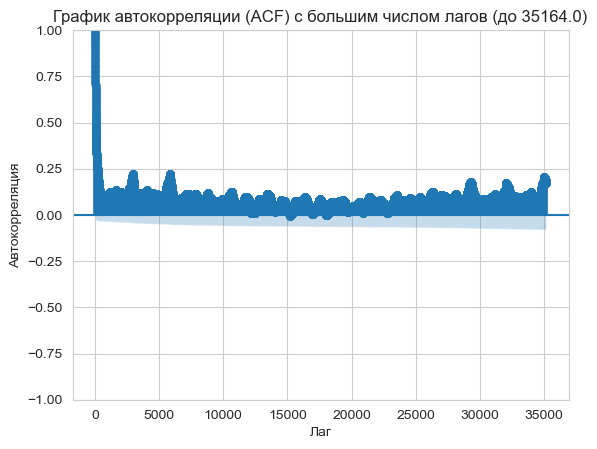

График ACF с большим числом лагов построен.


In [90]:

print("  Анализ автокорреляции (ACF) - Длинные лаги (Годовая сезонность) ---")

# Определяем примерное количество лагов для одного года (365 дней * 96 точек/день)
lags_one_year = 96 * 365.25
# Ограничиваем максимальное количество лагов для графика ACF (не больше, чем длина ряда - 1)
max_lags_for_plot = min(lags_one_year + 100, len(data_indexed) - 1)

try:
    plot_acf(data_indexed['value'].dropna(), lags=max_lags_for_plot)
    plt.title(f'График автокорреляции (ACF) с большим числом лагов (до {max_lags_for_plot})')
    plt.xlabel('Лаг')
    plt.ylabel('Автокорреляция')
    plt.grid(True)
    plt.show()
    print("График ACF с большим числом лагов построен.")
except Exception as e:
     print(f"Ошибка при построении ACF с большим числом лагов: {e}")

In [ ]:
Главная особенность этого графика — это четко выраженный пик (значимая положительная автокорреляция) в районе лага, соответствующего одному году.
Учитывая, что данные имеют 15-минутную частоту, один год составляет примерно 96×365≈35040 точек. 
Пик на графике ACF в этом районе ясно показывает, что значения временного ряда сильно коррелируют со значениями, которые были ровно год назад.

## Выводы из анализа временного ряда и обоснование выбора модели

На основе проведенного анализа временного ряда производства электроэнергии ветряными мельницами можно сделать следующие выводы:

* **Тренд:** Присутствует явный восходящий тренд на протяжении всего периода наблюдений (видно на графике ряда и по медленному затуханию ACF). Ряд является нестационарным.
* **Суточная сезонность:** Декомпозиция с суточным периодом показала, что суточная сезонность присутствует, но ее амплитуда относительно мала по сравнению с общим уровнем ряда и остаточными колебаниями. Это подтверждается не очень выраженными пиками на лагах, кратных 96, на графике ACF (короткие лаги).
* **Годовая сезонность:** Анализ ACF на больших лагах (около 35000) выявил сильную положительную автокорреляцию, что свидетельствует о ярко выраженной годовой сезонности. Уровень производства энергии повторяется примерно через год.
* **Остаточная изменчивость (Шум):** На графике декомпозиции видно, что остаточная компонента имеет большую амплитуду, что указывает на значительную изменчивость ряда, не объясняемую только трендом и простой сезонностью. Это связано с зависимостью от погодных условий (ветра), которые могут меняться непредсказуемо.

**Выбор модели:**

Для прогнозирования временных рядов с трендом и сезонностью хорошо подходят модели класса ARIMA/SARIMA или Prophet.

Изначально планировалось использовать SARIMA, как мощную модель для таких задач. Однако, попытка автоматического подбора параметров SARIMA  столкнулась с серьезными ограничениями по памяти, особенно при попытке учесть сильную годовую сезонность с очень большим периодом (примерно 35000 для 15-минутных данных). 

В связи с этим, в качестве альтернативы была выбрана модель **Prophet** .



In [93]:
print(" Разделение данных на обучающую и тестовую выборки ---")

# Определяем дату разделения - за 1 год до конца данных
end_date = data['time'].max()
split_date = end_date - pd.DateOffset(years=1)

# Разделяем данные
train_data = data[data['time'] <= split_date].copy()
test_data = data[data['time'] > split_date].copy()

# Для Prophet нужны колонки с названиями 'ds' (время) и 'y' (значение)
train_data = train_data.rename(columns={'time': 'ds', 'value': 'y'})
test_data = test_data.rename(columns={'time': 'ds', 'value': 'y'})

print(f"Размер обучающей выборки: {len(train_data)}")
print(f"Размер тестовой выборки (последний год): {len(test_data)}")
print(f"Дата разделения: {split_date}")
print(f"Первая дата в тестовой выборке: {test_data['ds'].min()}")
print(f"Последняя дата в обучающей выборке: {train_data['ds'].max()}")

 Разделение данных на обучающую и тестовую выборки ---
Размер обучающей выборки: 350526
Размер тестовой выборки (последний год): 35040
Дата разделения: 2020-12-30 07:45:00
Первая дата в тестовой выборке: 2020-12-30 08:00:00
Последняя дата в обучающей выборке: 2020-12-30 07:45:00


In [95]:
print(" Инициализация и обучение модели Prophet ---")

# Инициализация модели Prophet
# Включаем основные сезонности. Prophet автоматически определит их периоды.
# Устанавливаем uncertainty_samples=0 для отключения расчета интервалов и экономии памяти.
model = Prophet(
    yearly_seasonality=True,
    weekly_seasonality=True,
    daily_seasonality=True,
    uncertainty_samples=0
)

# Обучение модели на обучающей выборке
try:
    print("Начинается обучение модели Prophet...")
    model.fit(train_data)
    print("\nМодель Prophet успешно обучена.")
except Exception as e:
    print(f"\nОшибка при обучении модели Prophet: {e}")
    # exit() # Закомментировано на случай ошибки

 Инициализация и обучение модели Prophet ---
Начинается обучение модели Prophet...


02:00:40 - cmdstanpy - INFO - Chain [1] start processing
02:04:19 - cmdstanpy - INFO - Chain [1] done processing



Модель Prophet успешно обучена.


In [97]:
# Ячейка типа Code
print(" Создание будущих дат для прогноза ---")

# Создаем DataFrame для прогноза. Количество периодов равно длине тестовой выборки.
# Указываем частоту данных '15min'.
future = model.make_future_dataframe(periods=len(test_data), freq='15min')

print(f"Создан DataFrame для прогноза с {len(future)} датами.")
print("Первые 5 дат в DataFrame future:")
print(future.head())
print("\nПоследние 5 дат в DataFrame future:")
print(future.tail())

 Создание будущих дат для прогноза ---
Создан DataFrame для прогноза с 385520 датами.
Первые 5 дат в DataFrame future:
                   ds
0 2011-01-01 00:00:00
1 2011-01-01 00:15:00
2 2011-01-01 00:30:00
3 2011-01-01 00:45:00
4 2011-01-01 01:00:00

Последние 5 дат в DataFrame future:
                        ds
385515 2021-12-30 06:45:00
385516 2021-12-30 07:00:00
385517 2021-12-30 07:15:00
385518 2021-12-30 07:30:00
385519 2021-12-30 07:45:00


In [99]:
 
print("  Генерация прогноза ---")

# Метод predict возвращает DataFrame с прогнозом.
# При uncertainty_samples=0, будут только колонки ds, trend, yhat и компоненты сезонности.
forecast = model.predict(future)

print("\nПрогноз сгенерирован. Первые 5 строк DataFrame forecast:")
# Выводим только ds (время) и yhat (прогноз)
print(forecast[['ds', 'yhat']].head())


print("\nВсе колонки в DataFrame forecast:")
print(forecast.columns)

  Генерация прогноза ---

Прогноз сгенерирован. Первые 5 строк DataFrame forecast:
                   ds         yhat
0 2011-01-01 00:00:00  2299.021625
1 2011-01-01 00:15:00  2296.046853
2 2011-01-01 00:30:00  2289.587908
3 2011-01-01 00:45:00  2279.914430
4 2011-01-01 01:00:00  2267.460387

Все колонки в DataFrame forecast:
Index(['ds', 'trend', 'additive_terms', 'daily', 'weekly', 'yearly',
       'multiplicative_terms', 'yhat'],
      dtype='object')


In [105]:

print(" Оценка качества прогноза ---")
print("Оценка качества прогноза на тестовой выборке (последний год)...")

# Получаем последнюю дату из обучающей выборки
last_train_date = train_data['ds'].max()

# Извлекаем прогнозные значения только для периода СТРОГО ПОСЛЕ последней даты обучения
# Это гарантирует, что мы берем именно период тестовой выборки
forecast_test_period = forecast[forecast['ds'] > last_train_date].sort_values('ds')

# Убедимся, что тестовые данные тоже отсортированы
test_data_sorted = test_data.sort_values('ds')

# ПРОВЕРКА: Убедимся, что количество точек совпадает
print(f"\nКоличество точек в тестовой выборке: {len(test_data_sorted)}")
print(f"Количество точек в извлеченном прогнозном периоде: {len(forecast_test_period)}")

if len(test_data_sorted) != len(forecast_test_period):
    print("\nВнимание: Количество точек в тестовой выборке и прогнозном периоде НЕ СОВПАДАЕТ.")
    print("Метрики качества не могут быть рассчитаны напрямую. Требуется анализ данных вокруг точки разделения.")
else:
    print("\nКоличество точек совпадает. Приступаем к расчету метрик качества.")

    # Сравниваем фактические значения из test_data['y'] с прогнозными значениями из forecast_test_period['yhat']
    actual_values = test_data_sorted['y']
    predicted_values = forecast_test_period['yhat']

    # Рассчитываем метрики качества
    mae = mean_absolute_error(actual_values, predicted_values)
    mse = mean_squared_error(actual_values, predicted_values)
    rmse = np.sqrt(mse)

    print(f"\nМетрики качества прогноза на тестовой выборке (последний год):")
    print(f"Средняя абсолютная ошибка (MAE): {mae:.2f}")
    print(f"Среднеквадратичная ошибка (MSE): {mse:.2f}")
    print(f"Корень из среднеквадратичной ошибки (RMSE): {rmse:.2f}")

    # Переменные actual_values и predicted_values готовы для визуализации
    print("\nПеременные actual_values и predicted_values готовы для визуализации.")

 Оценка качества прогноза ---
Оценка качества прогноза на тестовой выборке (последний год)...

Количество точек в тестовой выборке: 35040
Количество точек в извлеченном прогнозном периоде: 35040

Количество точек совпадает. Приступаем к расчету метрик качества.

Метрики качества прогноза на тестовой выборке (последний год):
Средняя абсолютная ошибка (MAE): 2831.94
Среднеквадратичная ошибка (MSE): 12180727.29
Корень из среднеквадратичной ошибки (RMSE): 3490.09

Переменные actual_values и predicted_values готовы для визуализации.


MAE (2831.94) и RMSE (3490.09): Эти высокие значения прямо указывают на значительное среднее отклонение прогноза от фактических значений. Размер ошибки показывает, что для модели сложно предсказать высокоамплитудную статочную компоненту.

 Визуализация прогноза ---
Строим график фактических данных и прогноза...


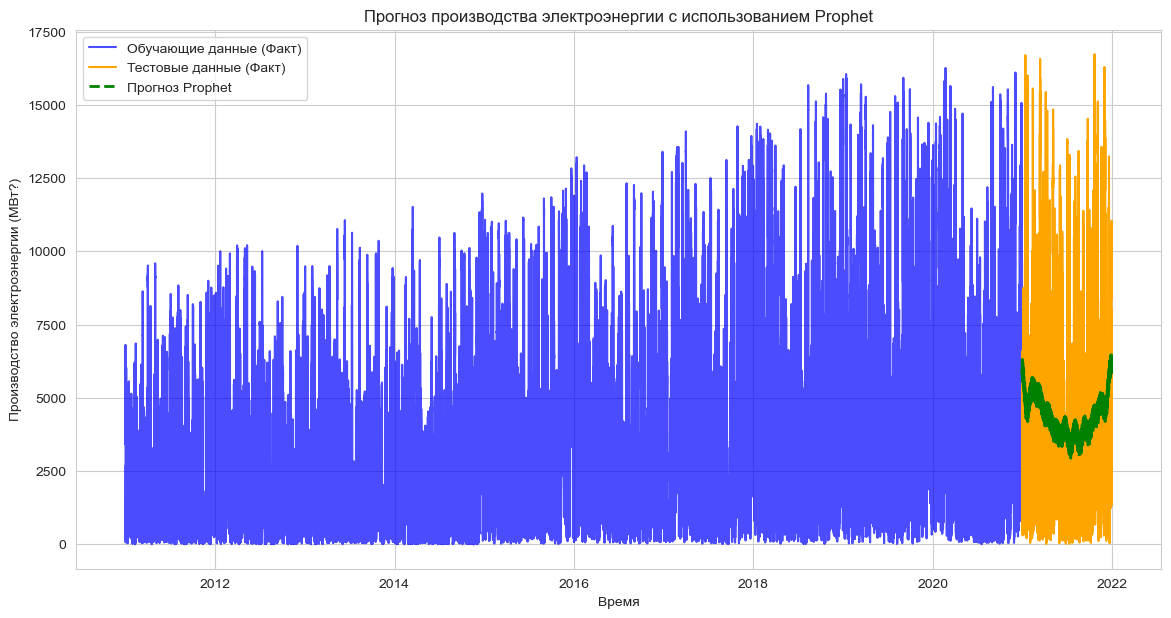

In [107]:

print(" Визуализация прогноза ---")
print("Строим график фактических данных и прогноза...")

plt.figure(figsize=(14, 7))

# Строим фактические данные (обучающая + тестовая выборки)
plt.plot(train_data['ds'], train_data['y'], label='Обучающие данные (Факт)', color='blue', alpha=0.7)
plt.plot(test_data_sorted['ds'], test_data_sorted['y'], label='Тестовые данные (Факт)', color='orange')

# Строим прогнозные значения для тестового периода
# Используем данные из forecast_test_period, т.к. они выровнены
plt.plot(forecast_test_period['ds'], forecast_test_period['yhat'], label='Прогноз Prophet', color='green', linestyle='--', linewidth=2)

plt.title('Прогноз производства электроэнергии с использованием Prophet')
plt.xlabel('Время')
plt.ylabel('Производство электроэнергии (МВт?)') # Уточните единицы
plt.legend()
plt.grid(True)
plt.show()

## Выводы

1.  **Анализ ряда:**
    * Временной ряд обладает выраженным восходящим трендом.
    * Присутствует как суточная, так и сильная годовая сезонность. При этом годовая сезонность (связанная, вероятно, с сезонными изменениями ветровой активности) оказалась более значимой, чем суточная.
    * Ряд также характеризуется высокой изменчивостью (большая остаточная компонента), что ожидаемо для данных, зависящих от погодных условий.

2.  **Выбор и обучение модели:**
    * Изначально рассматривалась модель SARIMA, однако из-за ограничений по памяти при попытке учесть сильную годовую сезонность на большом объеме данных, был выбран альтернативный подход.
    * Модель **Prophet** была успешно обучена на обучающей выборке, включая моделирование тренда и годовой, недельной и суточной сезонности. 

3.  **Прогнозирование и оценка качества:**
    * Модель Prophet сгенерировала прогноз на последний год временного ряда.
    * Оценка качества прогноза на тестовой выборке показала следующие результаты:
        * MAE: 2831.94
        * RMSE: 3490.09
    * Эти метрики отражают значительные колебания в фактических данных, которые модель не может полностью предсказать, так как они, вероятно, связаны с непериодическими погодными факторами.

4.  **Визуальная оценка прогноза:**
    * График прогноза показал, что модель Prophet хорошо уловила общий тренд и основные сезонные паттерны (в особенности годовую сезонность) в тестовом периоде.
    * Однако, прогноз представляет собой более сглаженную линию по сравнению с высокочастотными фактическими данными, что соответствует неспособности модели предсказать каждый конкретный всплеск или падение производства.



